In [9]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/atharvasoundankar/big-4-financial-risk-insights-2020-2025/big4_financial_risk_compliance.csv


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [11]:
df=pd.read_csv("/kaggle/input/datasets/atharvasoundankar/big-4-financial-risk-insights-2020-2025/big4_financial_risk_compliance.csv")
df.head()

,Year,Firm_Name,Total_Audit_Engagements,High_Risk_Cases,Compliance_Violations,Fraud_Cases_Detected,Industry_Affected,Total_Revenue_Impact,AI_Used_for_Auditing,Employee_Workload,Audit_Effectiveness_Score,Client_Satisfaction_Score
0,2020,PwC,2829,51,123,39,Healthcare,114.24,No,57,5.8,8.4
1,2022,Deloitte,3589,185,30,60,Healthcare,156.98,Yes,58,5.3,6.7
2,2020,PwC,2438,212,124,97,Healthcare,131.83,No,76,6.1,6.2
3,2021,PwC,2646,397,55,97,Healthcare,229.11,No,60,5.1,8.6
4,2020,PwC,2680,216,99,46,Healthcare,48.00,No,51,9.1,6.7


In [12]:
import os
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 安装CJK字体
!apt-get update -qq
!apt-get install -y -qq fonts-noto-cjk

# 查找并加载
cjk_path = None
for p in fm.findSystemFonts():
    if "NotoSansCJK" in p and "Regular" in p:
        cjk_path = p
        break

if cjk_path:
    fm.fontManager.addfont(cjk_path)
    font_name = fm.FontProperties(fname=cjk_path).get_name()
    plt.rcParams["font.sans-serif"] = [font_name]
    plt.rcParams["axes.unicode_minus"] = False
    print("成功加载标准Noto简体中文字体")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
成功加载标准Noto简体中文字体


In [13]:
import matplotlib.font_manager as fm
available_fonts = []
for font_path in fm.findSystemFonts():
    if "NotoSansCJK" in font_path and "Regular" in font_path:
        available_fonts.append(font_path)
        print(f"找到字体：{font_path}")

找到字体：/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc


===== 数据集基本信息 =====
样本量：100，字段数：12

字段列表：
- Year
- Firm_Name
- Total_Audit_Engagements
- High_Risk_Cases
- Compliance_Violations
- Fraud_Cases_Detected
- Industry_Affected
- Total_Revenue_Impact
- AI_Used_for_Auditing
- Employee_Workload
- Audit_Effectiveness_Score
- Client_Satisfaction_Score

前5行数据预览：
   Year Firm_Name  Total_Audit_Engagements  High_Risk_Cases  \
0  2020       PwC                     2829               51   
1  2022  Deloitte                     3589              185   
2  2020       PwC                     2438              212   
3  2021       PwC                     2646              397   
4  2020       PwC                     2680              216   

   Compliance_Violations  Fraud_Cases_Detected Industry_Affected  \
0                    123                    39        Healthcare   
1                     30                    60        Healthcare   
2                    124                    97        Healthcare   
3                     55                    9

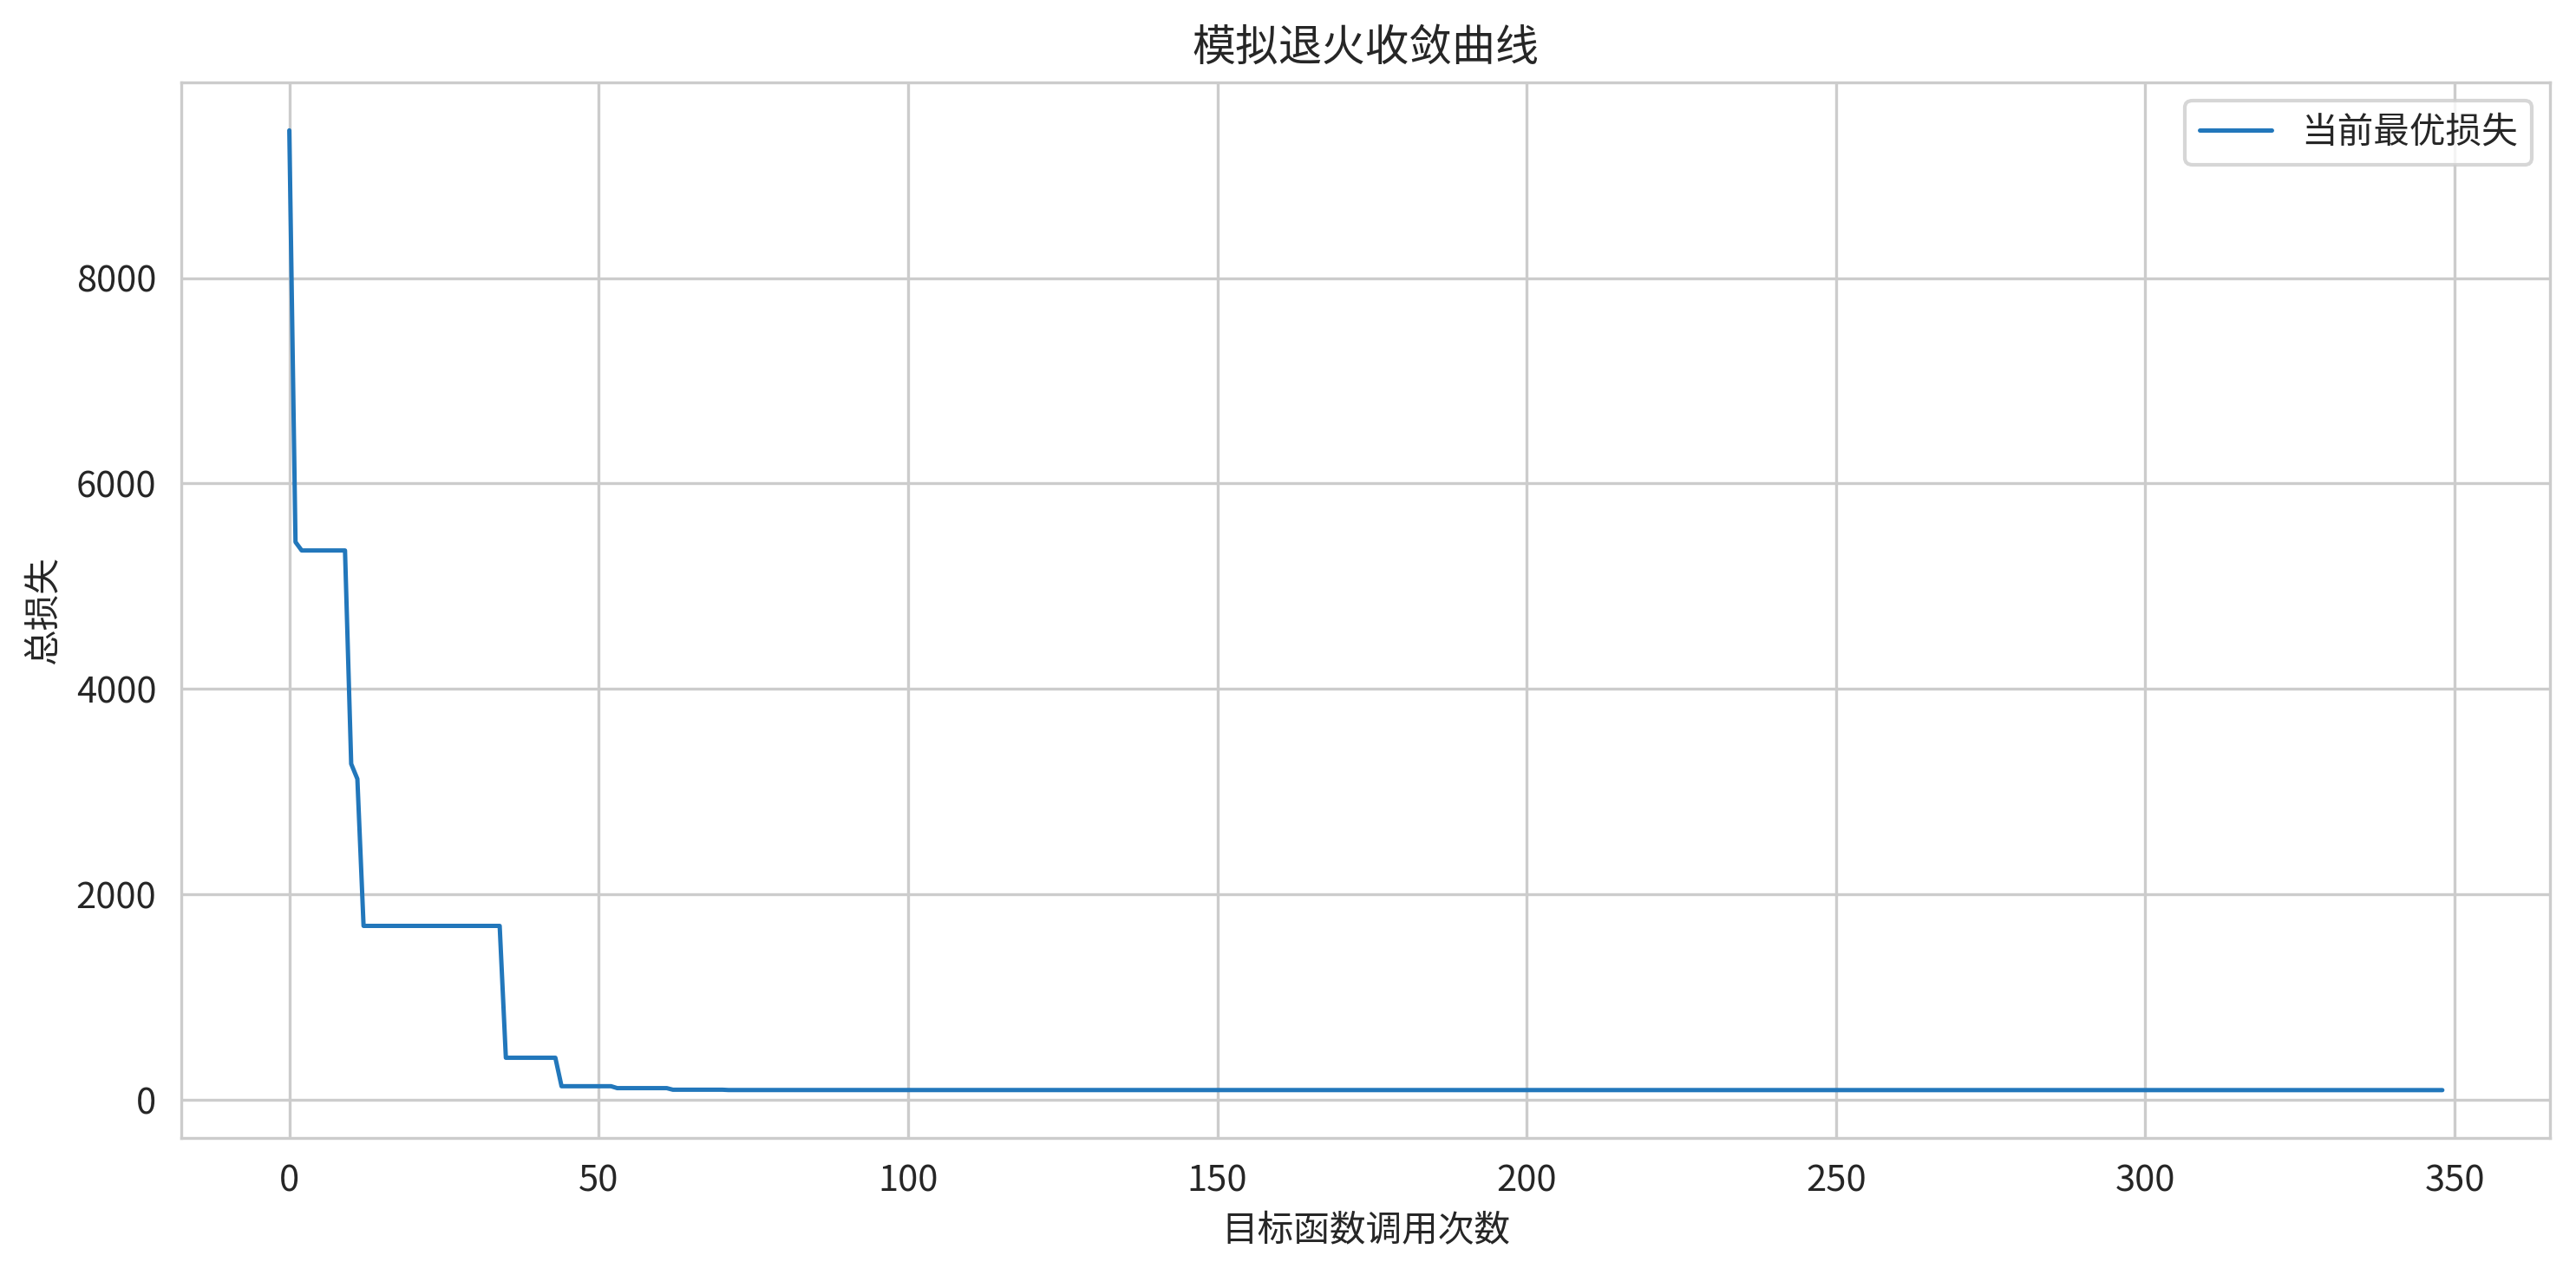


===== 全样本核心归因结果表 =====
                           变量名称  标准化边际系数  原始边际系数（万元/单位）  是否核心归因因子   损失贡献占比
0  Industry_Affected_Healthcare  -0.3016        -0.3016      True  27.0960
1        Industry_Affected_Tech  -0.2193        -0.2193      True  19.6997
2          AI_Used_for_Auditing  -0.1842        -0.1842      True  16.5488
3         Compliance_Violations   0.1663         0.1663      True  14.9391
4          Fraud_Cases_Detected   0.0970         0.0970      True   8.7193
5       Total_Audit_Engagements  -0.0875        -0.0875      True   7.8612
6               High_Risk_Cases   0.0521         0.0521      True   4.6775
7      Industry_Affected_Retail  -0.0051        -0.0051      True   0.4584

===== AI审计调节效应归因对比表 =====
                           变量名称  使用AI审计标准化系数  未使用AI审计标准化系数  系数差异（AI-无AI）
0         Compliance_Violations       0.1797        0.3262       -0.1465
1               High_Risk_Cases       0.0075        0.2888       -0.2813
2          Fraud_Cases_Detected       0.2153        0.1

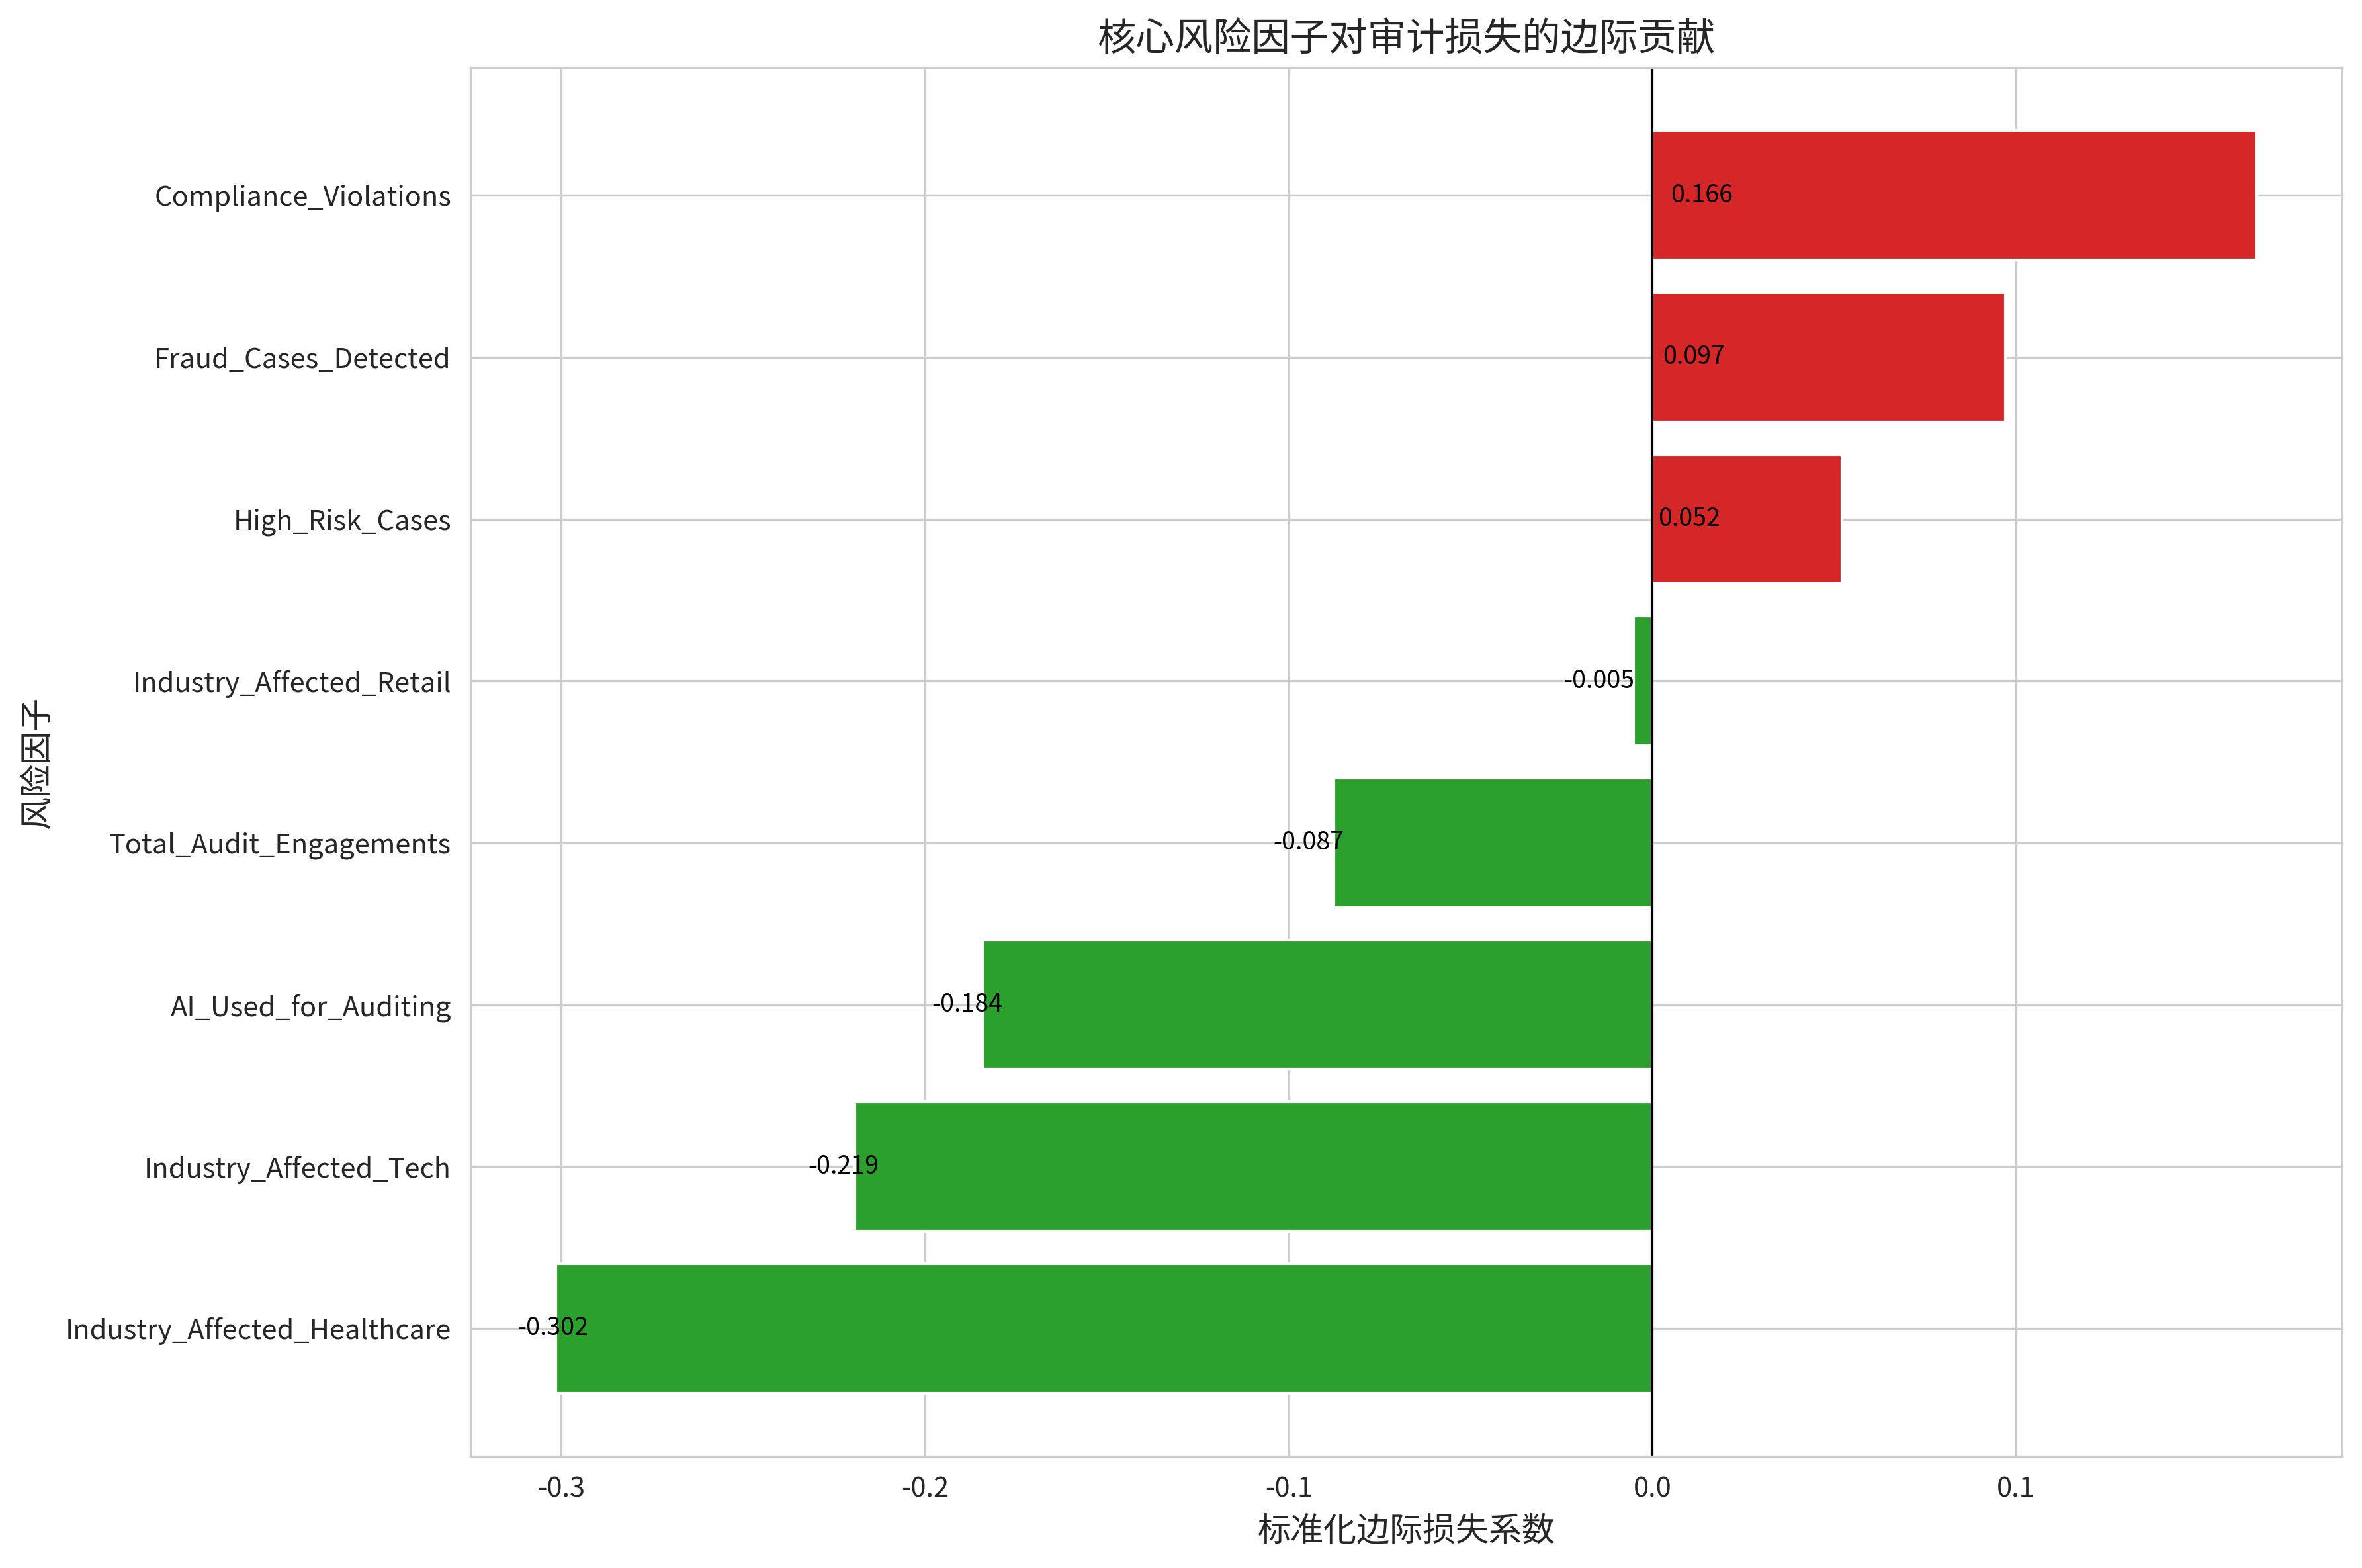

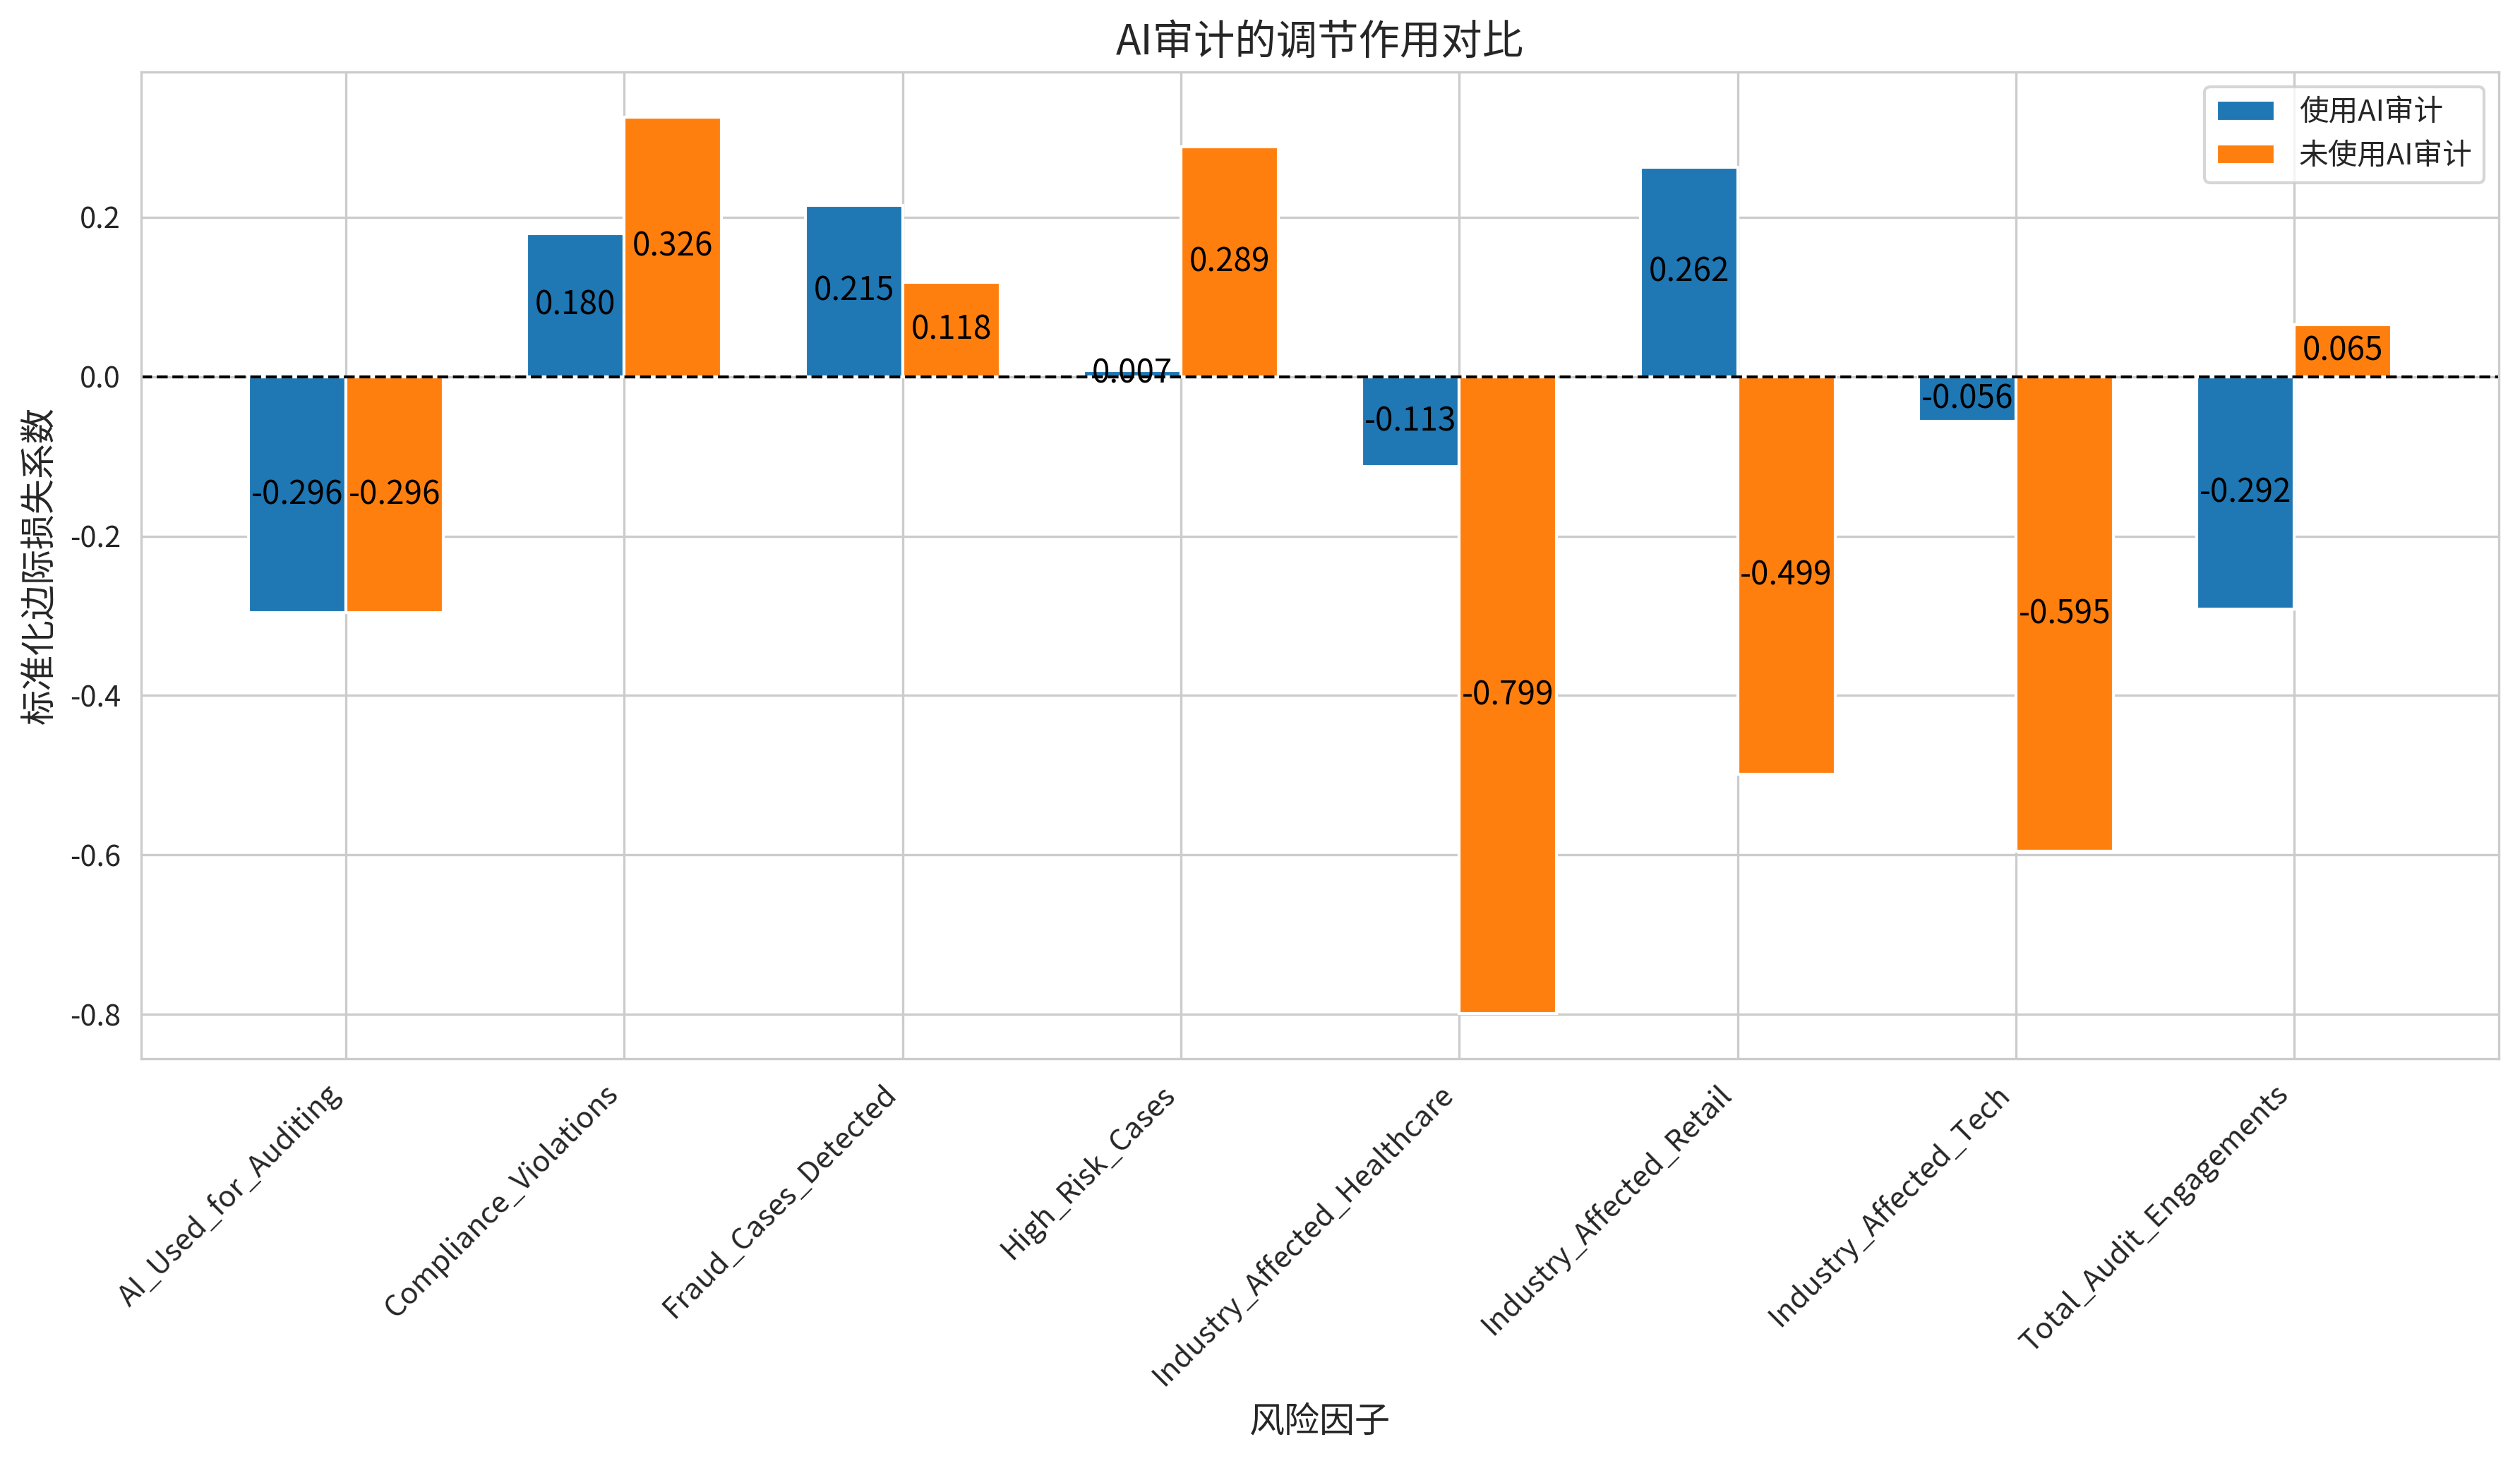

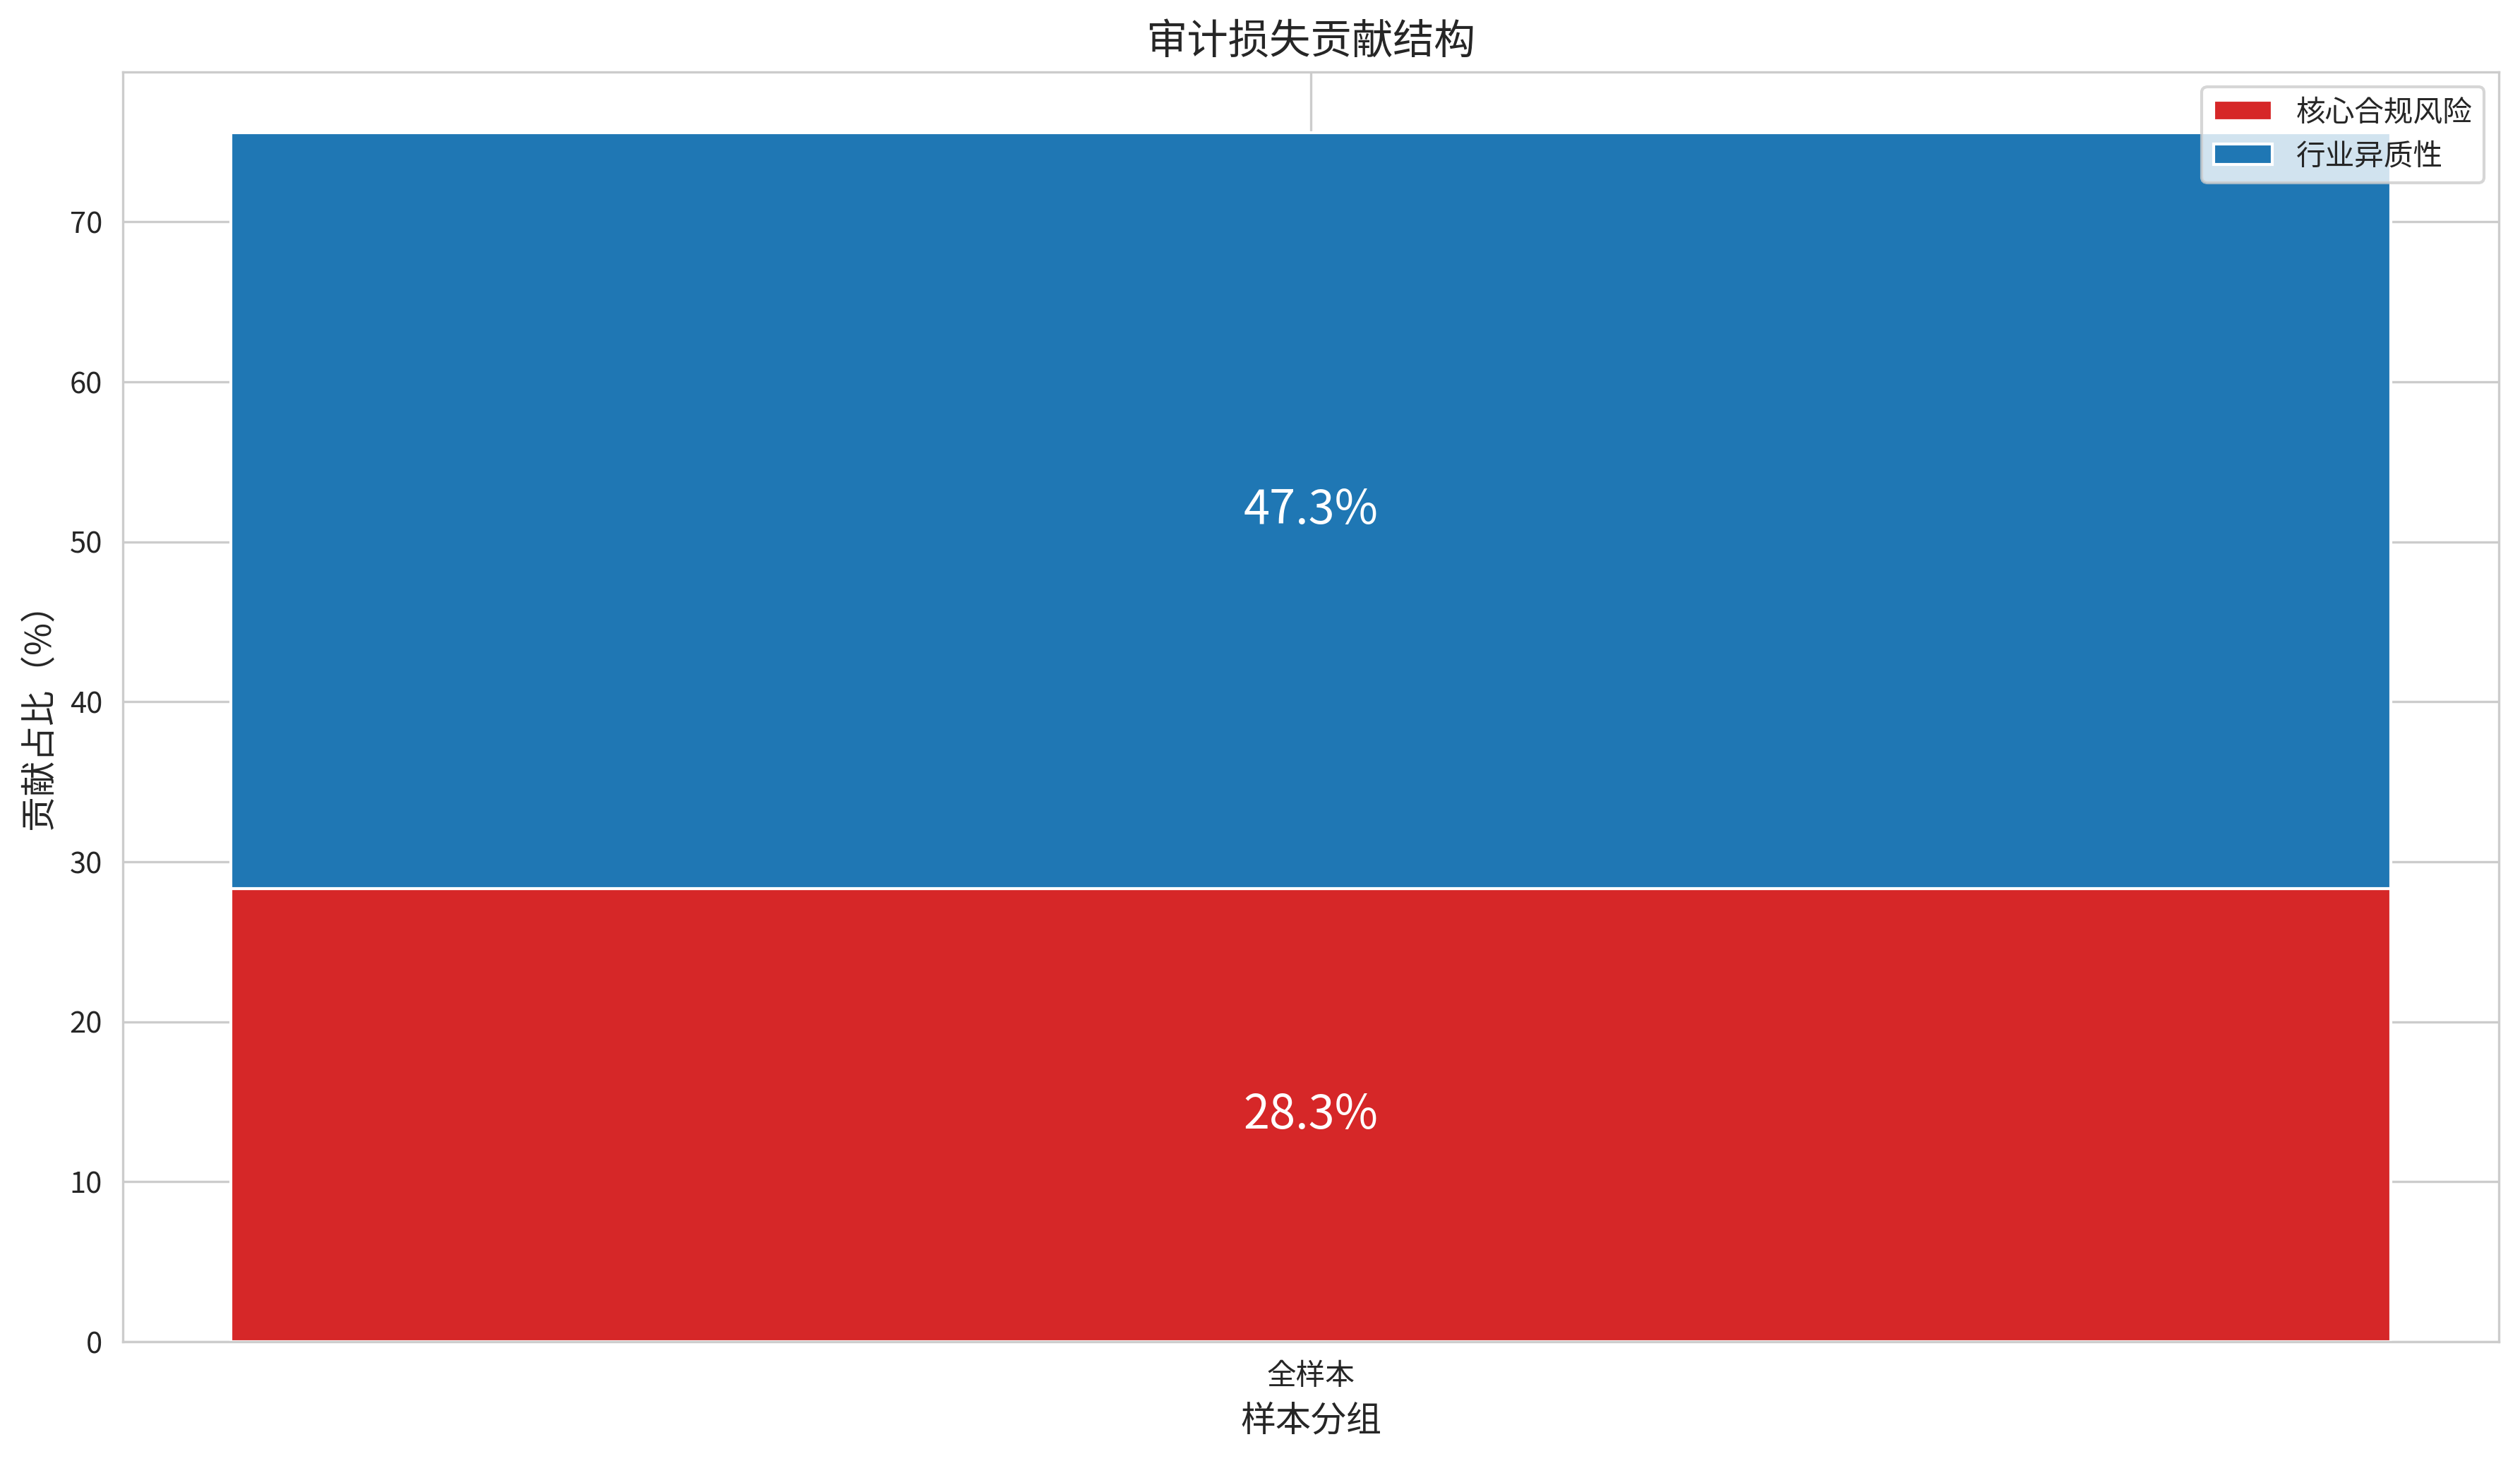

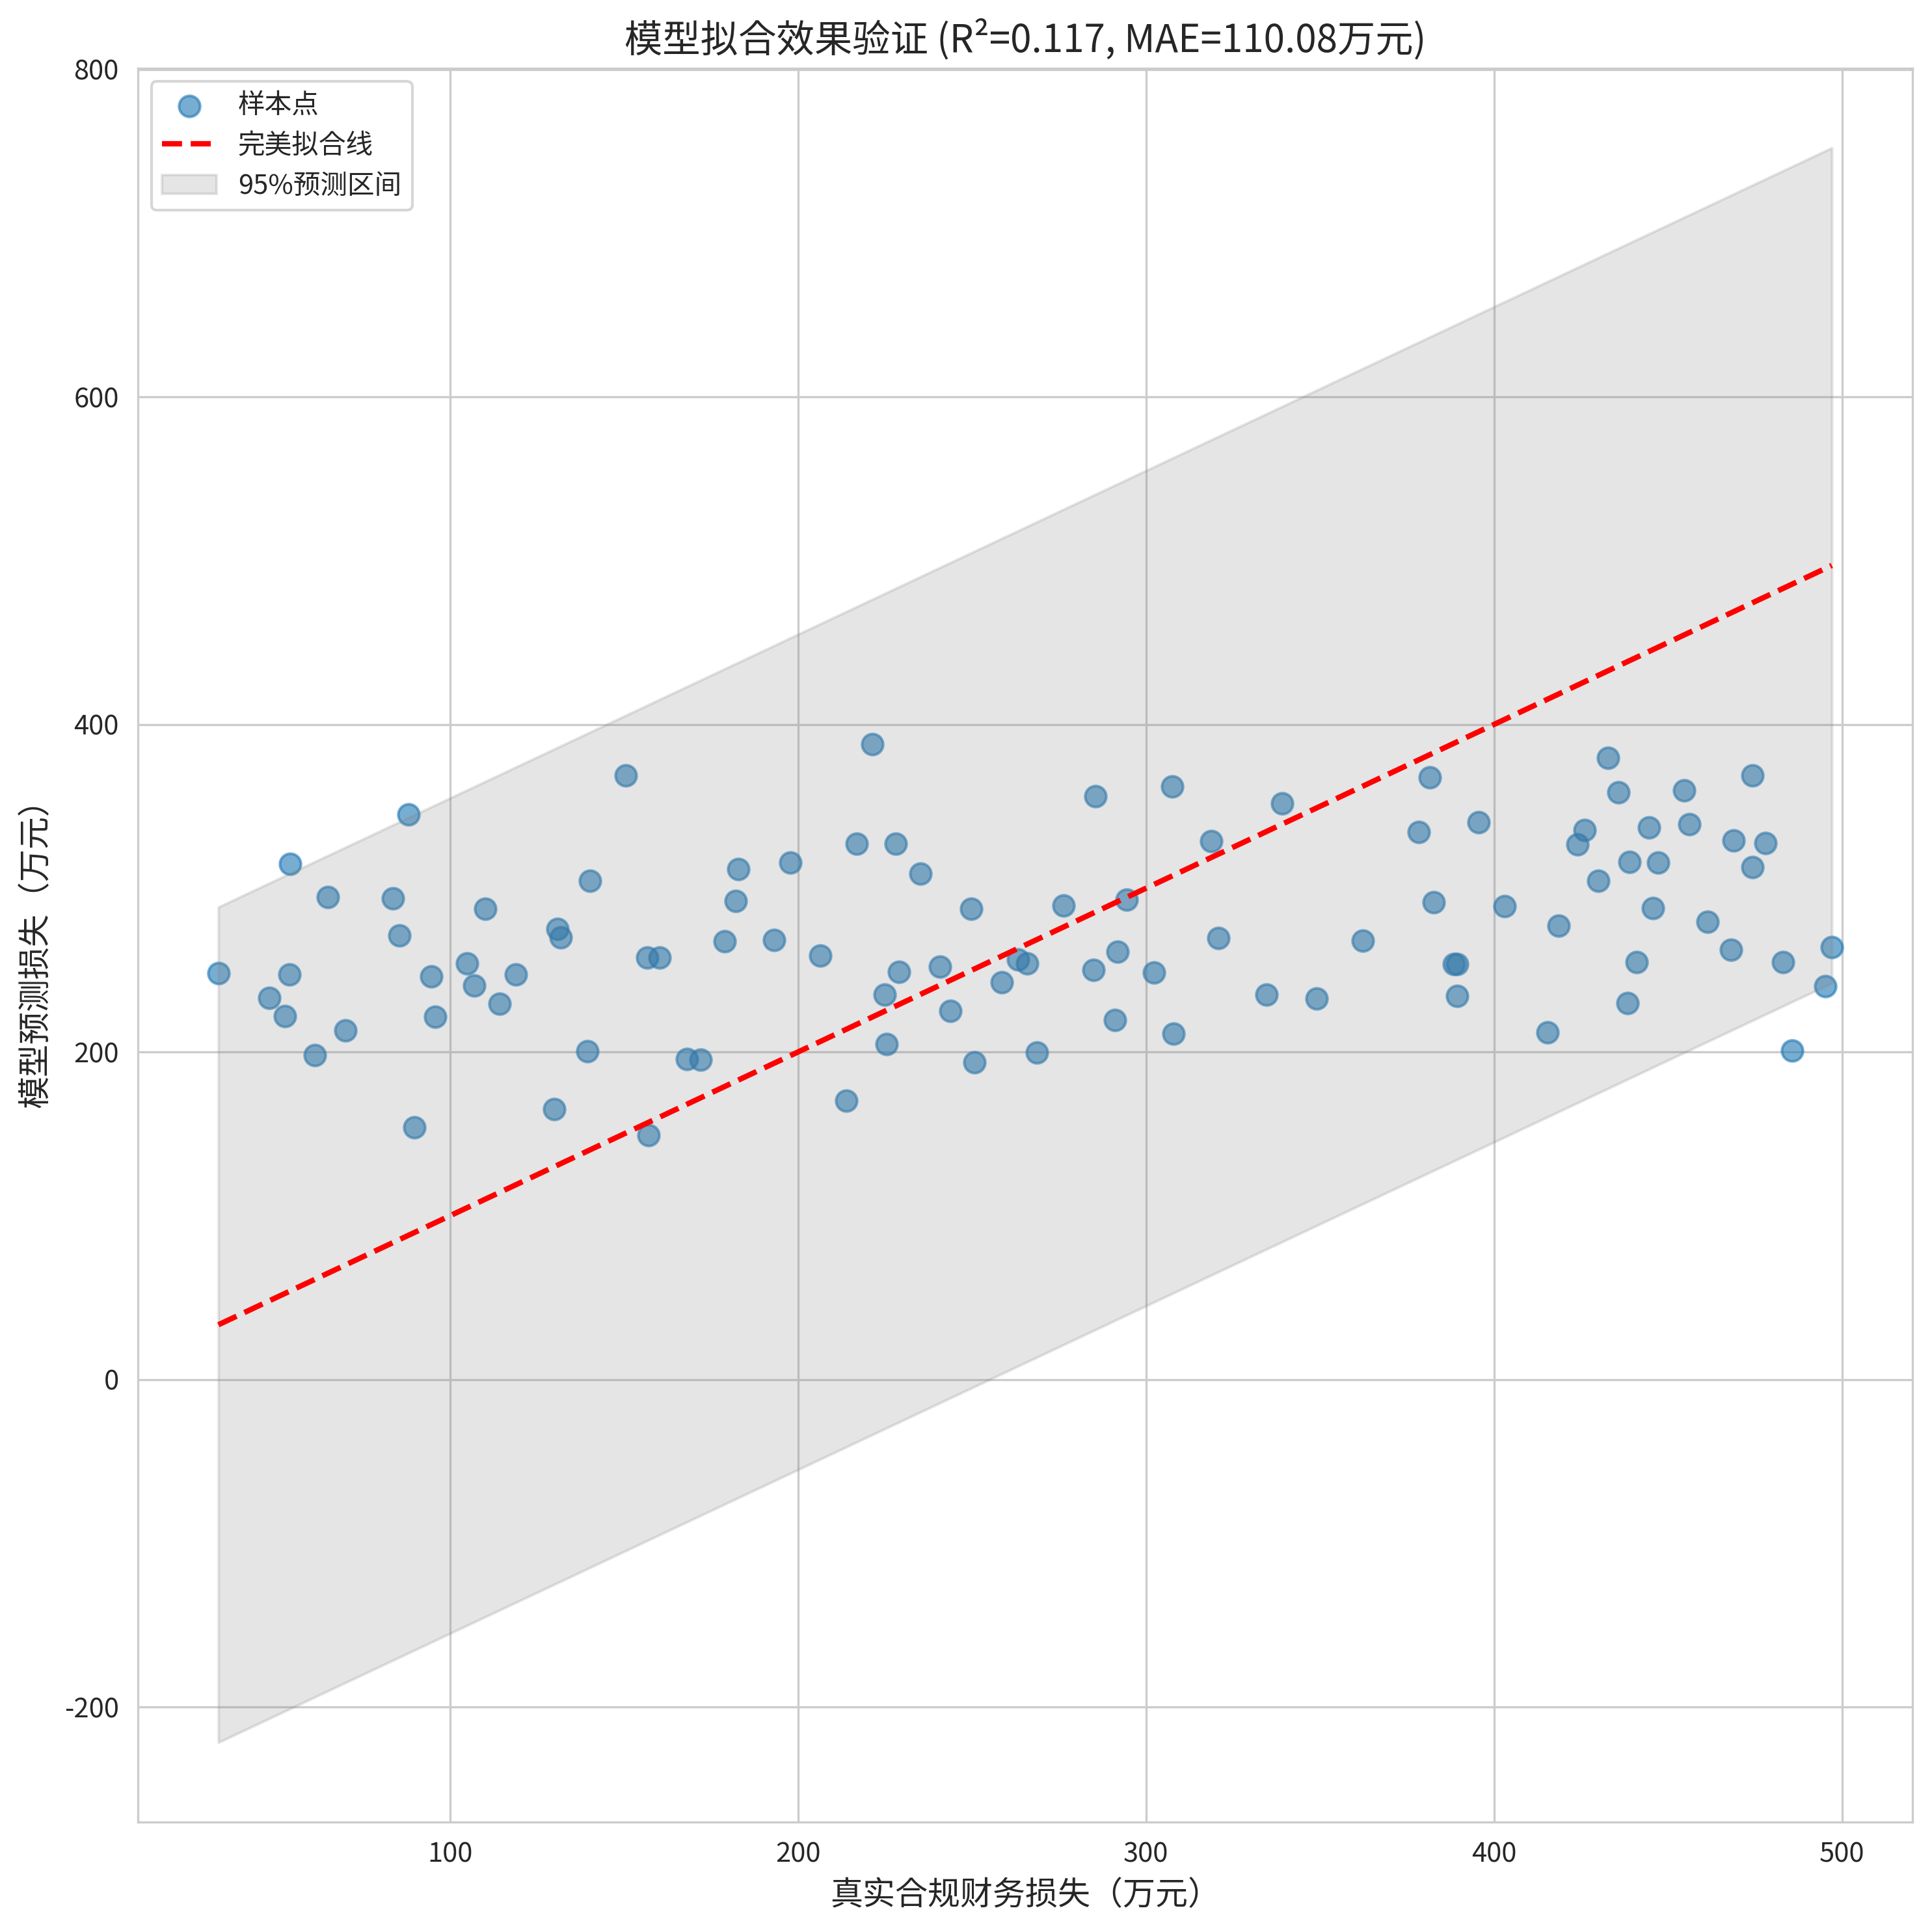


===== 所有结果已保存至/mnt目录 =====
1. 合规风险损失归因结果表.csv
2. AI审计调节效应对比表.csv
3. 合规风险定价公式.txt
4. 所有论文核心图表.png


In [ ]:
#1. 环境配置
# 安装所需依赖
!pip install pandas numpy scipy matplotlib seaborn statsmodels scikit-learn -q

# 导入核心库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import dual_annealing  # 模拟退火全局优化
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score, mean_absolute_error

# 全局配置
np.random.seed(42)  # 随机种子
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300  

# 路径配置
DATA_PATH = "/kaggle/input/datasets/atharvasoundankar/big-4-financial-risk-insights-2020-2025/big4_financial_risk_compliance.csv"

#2. 数据加载
# 读取数据集
df = pd.read_csv(DATA_PATH)

# 打印基本信息
print("===== 数据集基本信息 =====")
print(f"样本量：{df.shape[0]}，字段数：{df.shape[1]}")
print("\n字段列表：")
for col in df.columns:
    print(f"- {col}")
print("\n前5行数据：")
print(df.head())
print("\n缺失值统计：")
print(df.isnull().sum())

#3. 数据预处理
#缺失值处理 
# 核心字段缺失值直接删除，非核心字段用均值填充
core_cols = ['Total_Revenue_Impact', 'Compliance_Violations', 'High_Risk_Cases', 'Fraud_Cases_Detected']
df = df.dropna(subset=core_cols)
df = df.fillna(df.median(numeric_only=True))

#异常值处理
def winsorize(data, col, sigma=3):
    mean = data[col].mean()
    std = data[col].std()
    upper = mean + sigma * std
    lower = mean - sigma * std
    data[col] = np.clip(data[col], lower, upper)
    return data

continuous_cols = ['Total_Revenue_Impact', 'Compliance_Violations', 'High_Risk_Cases', 'Fraud_Cases_Detected', 'Total_Audit_Engagements', 'Employee_Workload']
for col in continuous_cols:
    df = winsorize(df, col)

#编码
# AI审计转为0/1
df['AI_Used_for_Auditing'] = df['AI_Used_for_Auditing'].map({'Yes': 1, 'No': 0})
# 行业独热编码，避免多重共线性，以金融为参照组
df = pd.get_dummies(df, columns=['Industry_Affected'], drop_first=True, dtype=int)

#变量定义
# 被解释变量
y = df['Total_Revenue_Impact'].values
# 解释变量
X_cols = [
    'Compliance_Violations', 'High_Risk_Cases', 'Fraud_Cases_Detected',  # 核心
    'AI_Used_for_Auditing',  # 调节变量
    'Total_Audit_Engagements', 'Employee_Workload'  # 控制变量
]
#独热编码加入
X_cols += [col for col in df.columns if col.startswith('Industry_')]
X = df[X_cols].values

#多重共线性筛选
def calculate_vif(X):
    vif = pd.DataFrame()
    vif['Variable'] = X_cols
    vif['VIF'] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return vif

# 循环删除VIF>10的变量
while True:
    vif_df = calculate_vif(X)
    max_vif = vif_df['VIF'].max()
    if max_vif <= 10:
        break
    drop_col = vif_df.loc[vif_df['VIF'] == max_vif, 'Variable'].iloc[0]
    print(f"删除高度共线性变量：{drop_col}，VIF={max_vif:.2f}")
    X_cols.remove(drop_col)
    X = df[X_cols].values

print("\n共线性筛选后变量列表")
for col in X_cols:
    print(f"- {col}")
print("\n最终VIF值：")
print(calculate_vif(X))

#标准化处理，消除量纲差异
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).flatten()

#贝叶斯先验设定
# 先验规则：
# 1. 核心：均值0.5，标准差0.2
# 2. AI审计：先验均值-0.3，标准差0.2
# 3. 行业变量：无先验，均值0，标准差10
prior_mean = np.zeros(X_scaled.shape[1])
prior_std = np.ones(X_scaled.shape[1]) * 10


for i, col in enumerate(X_cols):
    if col in ['Compliance_Violations', 'High_Risk_Cases', 'Fraud_Cases_Detected']:
        prior_mean[i] = 0.5
        prior_std[i] = 0.2
    elif col == 'AI_Used_for_Auditing':
        prior_mean[i] = -0.3
        prior_std[i] = 0.2

#4. 目标函数构建
# 目标函数：loss = 残差平方和 + L1正则项 + 先验负对数似然
def map_objective(beta, X, y, prior_mean, prior_std, lambda_reg=0.1):
    residuals = y - X @ beta
    ssr = np.sum(residuals ** 2)
    
    l1_penalty = lambda_reg * np.sum(np.abs(beta))
    
    prior_log_likelihood = np.sum(((beta - prior_mean) / prior_std) ** 2) / 2
    
    total_loss = ssr + l1_penalty + prior_log_likelihood
    return total_loss

#5. 模拟退火全局优化求解
n_vars = X_scaled.shape[1]
bounds = [(-5, 5) for _ in range(n_vars)]
#参数
initial_temp = 100.0
cooling_rate = 0.90
min_temp = 1e-3
max_iter = 15

loss_record = []
current_best = float("inf")
def wrapped_objective(beta, X, y, prior_mean, prior_std, lambda_reg):
    global current_best
    loss = map_objective(beta, X, y, prior_mean, prior_std, lambda_reg)
    if loss < current_best:
        current_best = loss
    loss_record.append(current_best)
    return loss
    
# 运行模拟退火
print("\n开始全局优化")
result = dual_annealing(
    func=wrapped_objective,
    bounds=bounds,
    args=(X_scaled, y_scaled, prior_mean, prior_std, 0.1),
    maxiter=max_iter,
    initial_temp=initial_temp,
    seed=42
)

# 输出优化结果
print(f"是否收敛：{'成功' if result.success else '失败'}")
print(f"最终目标函数值：{result.fun:.4f}")
print(f"迭代次数：{result.nit}")
print(f"收敛消息：{result.message}")




"""
加载中文字体
"""
import matplotlib as mpl
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False 

"""
加载结束
"""

# 绘图
plt.figure(figsize=(10, 5))
plt.plot(loss_record, color="#2277bb", linewidth=1.2, label="当前最优损失")
plt.xlabel("目标函数调用次数")
plt.ylabel("总损失")
plt.title("模拟退火收敛曲线")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/anneal_convergence.png", dpi=300, bbox_inches="tight")
plt.show()



beta_opt = result.x
beta_opt[np.abs(beta_opt) < 1e-3] = 0
beta_original = beta_opt * scaler.scale_[0] / scaler.scale_

#6. 核心归因分析

attribution_df = pd.DataFrame({
    '变量名称': X_cols,
    '标准化边际系数': beta_opt,
    '原始边际系数': beta_original,
    '是否核心归因因子': np.abs(beta_opt) >= 1e-3
})

total_abs_coef = np.sum(np.abs(beta_opt[np.abs(beta_opt) >= 1e-3]))
attribution_df['损失贡献占比'] = np.where(
    attribution_df['是否核心归因因子'],
    np.abs(attribution_df['标准化边际系数']) / total_abs_coef * 100,
    0
)


attribution_df = attribution_df.sort_values('损失贡献占比', ascending=False).reset_index(drop=True)

print("\n全样本核心归因结果表")
print(attribution_df.round(4))


# 按是否使用AI审计分组
df_ai_yes = df[df['AI_Used_for_Auditing'] == 1]
df_ai_no = df[df['AI_Used_for_Auditing'] == 0]

def group_attribution(group_df, X_cols, prior_mean, prior_std):
    y_group = group_df['Total_Revenue_Impact'].values
    X_group = group_df[X_cols].values
    # 标准化
    scaler_group = StandardScaler()
    X_group_scaled = scaler_group.fit_transform(X_group)
    y_group_scaled = scaler_group.fit_transform(y_group.reshape(-1, 1)).flatten()
    # 优化
    result_group = dual_annealing(
        func=map_objective,
        bounds=[(-5,5) for _ in range(X_group_scaled.shape[1])],
        args=(X_group_scaled, y_group_scaled, prior_mean, prior_std, 0.1),
        maxiter=5000,
        seed=42
    )
    beta_group = result_group.x
    beta_group[np.abs(beta_group) < 1e-3] = 0
    return beta_group, scaler_group

beta_ai_yes, scaler_ai_yes = group_attribution(df_ai_yes, X_cols, prior_mean, prior_std)
beta_ai_no, scaler_ai_no = group_attribution(df_ai_no, X_cols, prior_mean, prior_std)

# AI分组对比表
ai_compare_df = pd.DataFrame({
    '变量名称': X_cols,
    '使用AI审计标准化系数': beta_ai_yes,
    '未使用AI审计标准化系数': beta_ai_no,
    '系数差异（AI-无AI）': beta_ai_yes - beta_ai_no
})
print("\nAI审计调节效应归因对比")
print(ai_compare_df.round(4))


core_factors = attribution_df[attribution_df['是否核心归因因子']]

pricing_formula = f"预期审计损失 = {scaler.mean_[0]:.2f}万元\n"
for idx, row in core_factors.iterrows():
    sign = "+" if row['原始边际系数'] > 0 else ""
    pricing_formula += f"{sign}{row['原始边际系数']:.4f}万元 × {row['变量名称']}\n"

print("\n标准化风险定价公式")
print(pricing_formula)

#7.可视化图表

def record_objective(beta, X, y, prior_mean, prior_std, lambda_reg=0.1):
    global loss_history
    loss_history.append(map_objective(beta, X, y, prior_mean, prior_std, lambda_reg))


import matplotlib.pyplot as plt

core_df = attribution_df[attribution_df['是否核心归因因子']].sort_values('标准化边际系数', ascending=True)
plt.figure(figsize=(12, 8))
colors = ['#d62728' if x > 0 else '#2ca02c' for x in core_df['标准化边际系数']]
plt.barh(core_df['变量名称'], core_df['标准化边际系数'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('标准化边际损失系数', fontsize=12)
plt.ylabel('风险因子', fontsize=12)
plt.title('核心风险因子对审计损失的边际贡献', fontsize=14, fontweight='bold')

for i, v in enumerate(core_df['标准化边际系数']):
    if v > 0:
        text_x = v * 0.03
        align = 'left'
        text_color = "black"
    else:
        text_x = v * 0.97
        align = 'right'
        text_color = "black"
    plt.text(
        text_x,
        i,
        f'{v:.3f}',
        va='center',
        ha=align,
        fontsize=9,
        color=text_color
    )

plt.subplots_adjust(left=0.18)
plt.tight_layout()
plt.savefig('/kaggle/working/核心风险因子边际系数.png', dpi=300, bbox_inches='tight')
plt.show()


import numpy as np
core_vars = core_df['变量名称'].tolist()
ai_compare_core = ai_compare_df[ai_compare_df['变量名称'].isin(core_vars)].sort_values('变量名称')
x = np.arange(len(ai_compare_core))
width = 0.35

plt.figure(figsize=(12, 7))
bar_ai = plt.bar(x - width/2, ai_compare_core['使用AI审计标准化系数'], width, label='使用AI审计', color='#1f77b4')
bar_noai = plt.bar(x + width/2, ai_compare_core['未使用AI审计标准化系数'], width, label='未使用AI审计', color='#ff7f0e')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

for bar in bar_ai:
    val = bar.get_height()
    mid_y = val / 2
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mid_y,
        f"{val:.3f}",
        ha="center", va="center",
        color="black", fontsize=11, fontweight="bold"
    )

for bar in bar_noai:
    val = bar.get_height()
    mid_y = val / 2
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mid_y,
        f"{val:.3f}",
        ha="center", va="center",
        color="black", fontsize=11, fontweight="bold"
    )

plt.xlabel('风险因子', fontsize=12)
plt.ylabel('标准化边际损失系数', fontsize=12)
plt.title('AI审计的调节作用对比', fontsize=14, fontweight='bold')
plt.xticks(x, ai_compare_core['变量名称'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/AI审计调节效应对比.png', dpi=300, bbox_inches='tight')
plt.show()


industry_cols = [col for col in X_cols if col.startswith('Industry_')]
industry_names = [col.replace('Industry_', '') for col in industry_cols]


industry_data = attribution_df[attribution_df['变量名称'].isin(industry_cols)]
industry_sum = industry_data['损失贡献占比'].sum()

risk_data = attribution_df[attribution_df['变量名称'].isin(['Compliance_Violations', 'High_Risk_Cases', 'Fraud_Cases_Detected'])]
risk_sum = risk_data['损失贡献占比'].sum()

plt.figure(figsize=(12, 7))

bar_risk = plt.bar(['全样本'], [risk_sum], label='核心合规风险', color='#d62728')

bar_industry = plt.bar(['全样本'], [industry_sum], bottom=[risk_sum], label='行业异质性', color='#1f77b4')

for bar in bar_risk:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f"{height:.1f}%",
        ha="center", va="center",
        color="white", fontsize=16, fontweight="bold"
    )

for bar in bar_industry:
    height = bar.get_height()
    base_height = bar.get_y()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        base_height + height / 2,
        f"{height:.1f}%",
        ha="center", va="center",
        color="white", fontsize=16, fontweight="bold"
    )

plt.xlabel('样本分组', fontsize=12)
plt.ylabel('贡献占比（%）', fontsize=12)
plt.title('审计损失贡献结构', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/损失贡献结构.png', dpi=300, bbox_inches='tight')
plt.show()

y_pred_scaled = X_scaled @ beta_opt
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler.inverse_transform(y_scaled.reshape(-1, 1)).flatten()

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

plt.figure(figsize=(10, 10))
plt.scatter(y_true, y_pred, alpha=0.6, color='#1f77b4', s=60, label='样本点')

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='完美拟合线')

residuals = y_true - y_pred
std_resid = np.std(residuals)
plt.fill_between([min_val, max_val], [min_val - 1.96*std_resid, max_val - 1.96*std_resid], 
                 [min_val + 1.96*std_resid, max_val + 1.96*std_resid], 
                 color='gray', alpha=0.2, label='95%预测区间')
plt.xlabel('真实合规财务损失（万元）', fontsize=12)
plt.ylabel('模型预测损失（万元）', fontsize=12)
plt.title(f'模型拟合效果验证 (R²={r2:.3f}, MAE={mae:.2f}万元)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/模型拟合效果验证.png', dpi=300, bbox_inches='tight')
plt.show()



attribution_df.to_csv('/kaggle/working/归因结果表.csv', index=False, encoding='utf-8-sig')

ai_compare_df.to_csv('/kaggle/working/AI审计调节效应.csv', index=False, encoding='utf-8-sig')

with open('/kaggle/working/定价公式.txt', 'w', encoding='utf-8') as f:
    f.write(pricing_formula)

